In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_excel("/Users/asmitabaul/Downloads/Wind Energy Anantapur.xlsx")

In [7]:
data.head()

,YEAR,MO,DY,WS50M,T2M,WS10M
0,2025,4,1,6.26,29.93,4.39
1,2025,4,2,3.85,30.08,2.46
2,2025,4,3,3.06,28.91,2.25
3,2025,4,4,3.59,28.58,2.51
4,2025,4,5,3.94,29.08,2.67


In [8]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    365 non-null    int64  
 1   MO      365 non-null    int64  
 2   DY      365 non-null    int64  
 3   WS50M   365 non-null    float64
 4   T2M     365 non-null    float64
 5   WS10M   365 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.2 KB


,YEAR,MO,DY,WS50M,T2M,WS10M
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2025.246575,6.526027,15.720548,6.182301,25.959370,4.429370
std,0.431609,3.452584,8.808321,2.152625,3.264146,1.842634
min,2025.000000,1.000000,1.000000,1.410000,18.590000,0.910000
25%,2025.000000,4.000000,8.000000,4.720000,23.940000,3.120000
50%,2025.000000,7.000000,16.000000,5.800000,26.070000,3.910000
75%,2025.000000,10.000000,23.000000,7.180000,27.940000,5.360000
max,2026.000000,12.000000,31.000000,12.880000,33.660000,10.110000


In [5]:
data.isnull().sum()

YEAR     0
MO       0
DY       0
WS50M    0
T2M      0
WS10M    0
dtype: int64

In [12]:
data['Date'] = pd.to_datetime({
    'year': data['YEAR'],
    'month': data['MO'],
    'day': data['DY']
})

data['Month'] = data['Date'].dt.month

data['Power'] = data['WS50M'] ** 3

In [13]:
data.head()

,YEAR,MO,DY,WS50M,T2M,WS10M,Date,Month,Power
0,2025,4,1,6.26,29.93,4.39,2025-04-01,4,245.314376
1,2025,4,2,3.85,30.08,2.46,2025-04-02,4,57.066625
2,2025,4,3,3.06,28.91,2.25,2025-04-03,4,28.652616
3,2025,4,4,3.59,28.58,2.51,2025-04-04,4,46.268279
4,2025,4,5,3.94,29.08,2.67,2025-04-05,4,61.162984


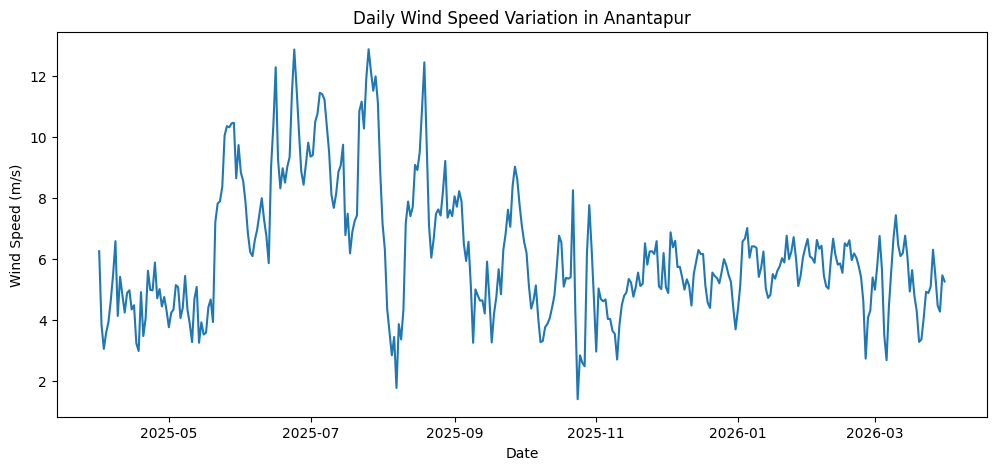

In [18]:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['WS50M'])
plt.title("Daily Wind Speed Variation in Anantapur")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.show()

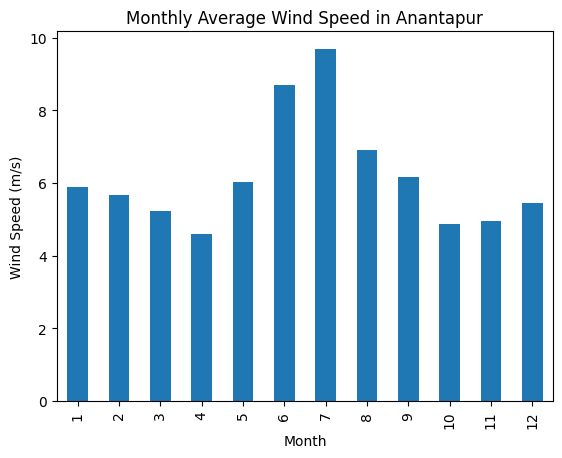

In [19]:
monthly = data.groupby('MO')['WS50M'].mean()

plt.figure()
monthly.plot(kind='bar')
plt.title("Monthly Average Wind Speed in Anantapur")
plt.xlabel("Month")
plt.ylabel("Wind Speed (m/s)")
plt.show()

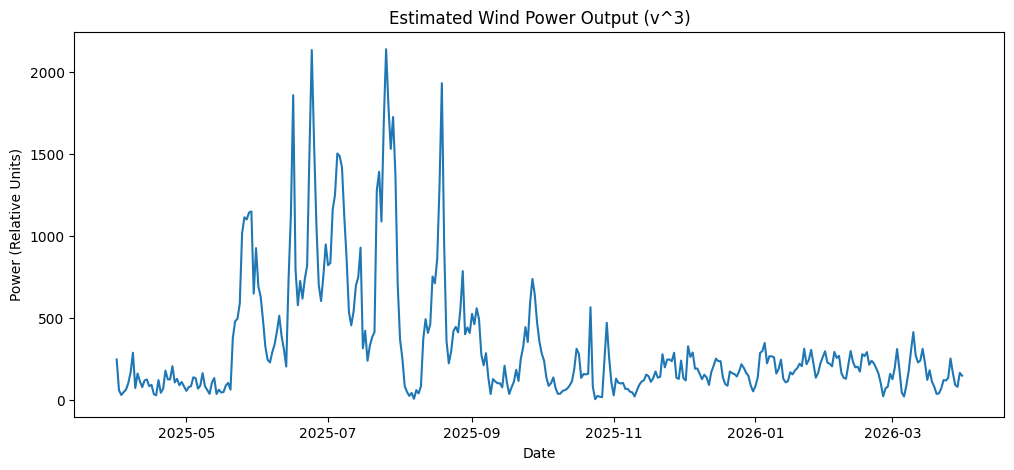

In [22]:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Power'])
plt.title("Estimated Wind Power Output (v^3)")
plt.xlabel("Date")
plt.ylabel("Power (Relative Units)")
plt.show()

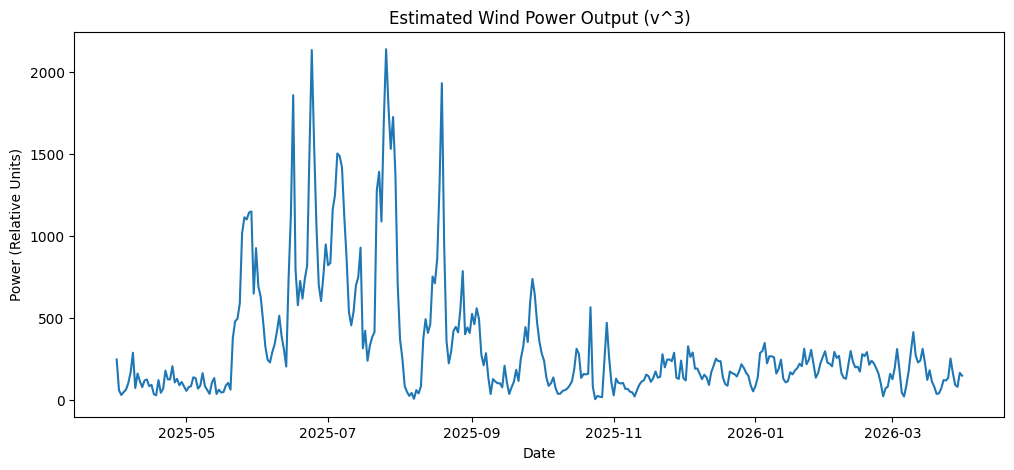

In [25]:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Power'])
plt.title("Estimated Wind Power Output (v^3)")
plt.xlabel("Date")
plt.ylabel("Power (Relative Units)")
plt.show()

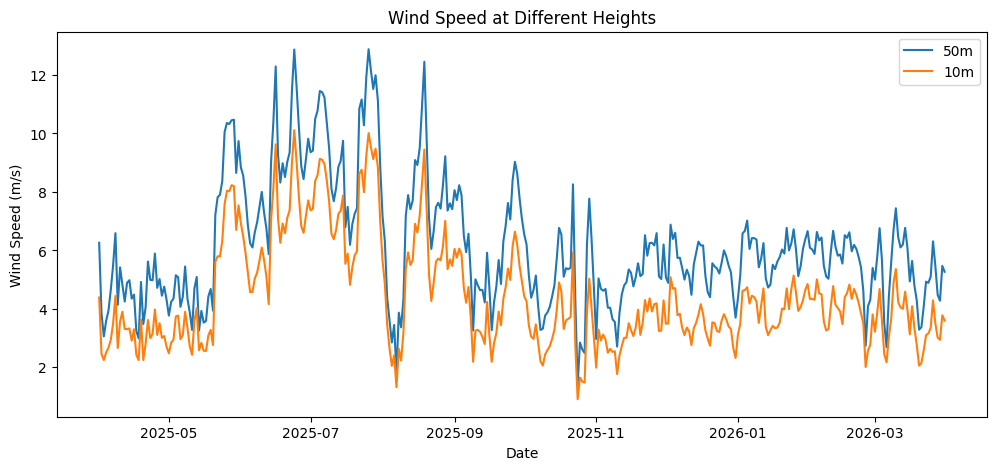

In [27]:
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['WS50M'], label='50m')
plt.plot(data['Date'], data['WS10M'], label='10m')
plt.title("Wind Speed at Different Heights")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.show()

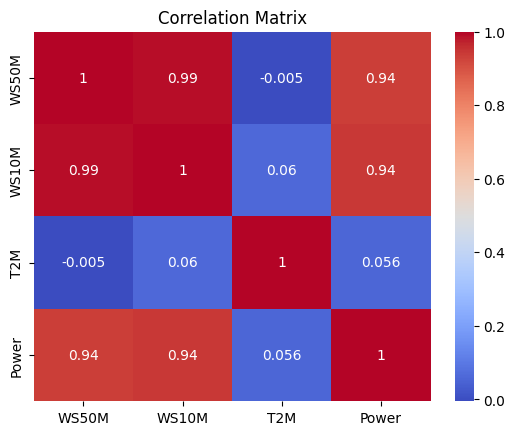

In [29]:
import seaborn as sns

sns.heatmap(data[['WS50M','WS10M','T2M','Power']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()